In [352]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import os

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898|21' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [353]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = []
MPKI_MIN = 0.0
WPKI_MIN = 2.5

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, reference_wpki: dict, mpki_min=MPKI_MIN, wpki_min=WPKI_MIN) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items()\
                  if w not in EXCLUDE\
                  and reference_mpki[w] >= mpki_min\
                  and reference_wpki[w] >= wpki_min }
    return out

In [354]:
baseline_stats = read_csv_file('baseline.csv')
reference_mpki = { w: stats['MPKI'] for (w,stats) in baseline_stats.items() }
reference_wpki = { w: stats['WPKI'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)
print(reference_wpki)

{'wrf': 19.295237998016372, 'perlbench': 0.062179974818963014, 'roms': 7.944433209568, 'gcc': 17.789238188333865, 'cam4': 5.634347278269818, 'cactubssn': 6.342251101488304, 'exchange2': 8.999999775000006e-05, 'leela': 0.017686246883762916, 'nab': 0.16322369299897788, 'x264': 0.15105999735645004, 'lbm': 33.901639942555875, 'xz': 2.0769545444449986, 'imagick': 0.03907874623316926, 'omnetpp': 12.007714765824174, 'pop2': 4.326189407176214, 'bwaves': 17.316351403189312, 'mcf': 15.166041696879335, 'fotonik3d': 18.242209499478296, 'xalancbmk': 1.9894455895579637, 'deepsjeng': 0.2956822159235451, 'bfscc': 19.095682484825215, 'triangle': 8.70978202018996, 'pagerankdelta': 19.412979590131364, 'bfs-bitvector': 16.901567007736485, 'components-shortcut': 37.20495905344855, 'radii': 44.786041393680186, 'bc': 25.442362957439396, 'cf': 16.124666513438548, 'mis': 19.420007087716254, 'bfs': 16.747169268715666, 'components': 40.53236114646427, 'pagerank': 36.44546194600682, 'bellmanford': 29.458691072984

In [355]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list, negate=False, percentage=False, plot_best_of_all=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki, reference_wpki=reference_wpki)

    n_labels = len(builds)
    if plot_best_of_all:
        n_labels += 1
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0

    gmean_list = []

    best_of_all = [-100 for _ in baseline_ipc_list]
    workload_order = list(baseline_ipc_list.keys())
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        X = np.arange(len(ipc_list)+1)
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in workload_order ]
        best_of_all = [max(max(best_of_all[i], Y[i]), 1.0) for i in range(len(Y))]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y

        for (ii, w) in enumerate(workload_order):
            print(f'{b}\t{w} speedup: {Y[ii]}')
        print('----------------------------')
            
        gmean_list.append(Y[-1])
        ax.bar(X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width

    if plot_best_of_all:
        best_of_all.append(sp.stats.gmean(best_of_all))
        best_of_all = np.array(best_of_all)
        if percentage:
            best_of_all = (best_of_all-1) * 100
        if negate:
            best_of_all = best_of_all

        gmean_list.append(best_of_all[-1])
        ax.bar(X+off, best_of_all, width, color=C6, label='BoA', zorder=3, edgecolor='k')
    
    # Setup anything else that is remaining:
    workload_order.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(X + (len(builds)-2)/2 * width, workload_order, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)

    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')

    if plot_best_of_all:
        print(f'{stat_name} GMEAN of BoA\t{gmean_list[-1]:.3f}')
    print('----------------------------')

wcache	wrf speedup: -0.9550058250362814
wcache	roms speedup: 0.5586677504150872
wcache	cam4 speedup: -1.8005098712366774
wcache	lbm speedup: 4.653462227868266
wcache	omnetpp speedup: 0.4289633909752899
wcache	bwaves speedup: 2.6386814607408438
wcache	fotonik3d speedup: 2.4064527385193157
wcache	triangle speedup: 0.13936904485969404
wcache	pagerankdelta speedup: 1.0219813145528445
wcache	radii speedup: 1.9322772022760226
wcache	bc speedup: 1.7193245252300038
wcache	cf speedup: 2.902898973232726
wcache	mis speedup: -0.37128422142773676
wcache	pagerank speedup: 0.644326569458431
wcache	bellmanford speedup: 0.609334807550499
wcache	whiskey speedup: 0.6210463971727975
wcache	charlie speedup: 1.0649312970602232
wcache	merced speedup: 1.2344115994416205
wcache	delta speedup: 0.6968987935442206
----------------------------
IPC GMEAN of wcache	1.050
IPC GMEAN of BoA	1.218
----------------------------


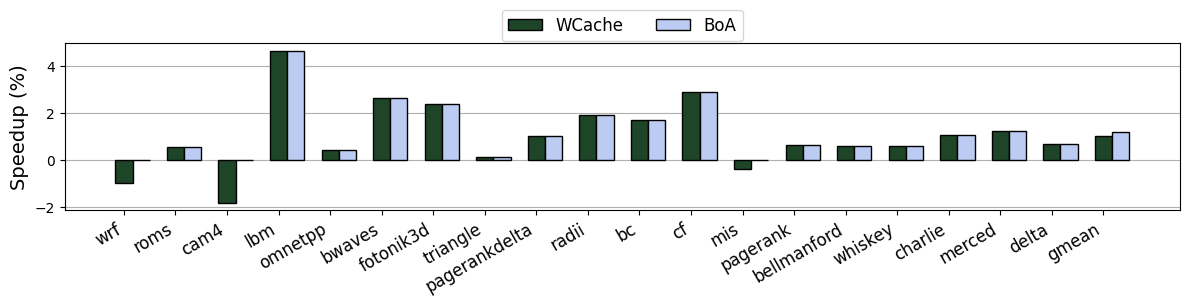

In [356]:
# Main evaluations:
plot_relative_stat('plots/main_evals_lru.pdf',
                   ['baseline', 'wcache'],
                   'IPC',
                   'Speedup (%)',
                   ['WCache', 'WCache_New'],
                   [C3, C1, C4],
                   percentage=True, plot_best_of_all=True)

In [347]:
### LRU SRAM OVERHEADS

LLC_CAPACITY = 16*1024*1024 * 8
LLC_ASSOC = 16
WCACHE_SAMPLED_SETS = 64
DRAM_CHANNELS = 2
DRAM_BANKS = 32

baseline_tagdir_size = (LLC_CAPACITY/(64*8)) * (48-14-6 + 2)

wcache_counters = LLC_ASSOC*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006754557291666
664.0


In [348]:
## SRRIP SRAM OVERHEADS
RRIP_BITS=2

wcache_counters = (2**RRIP_BITS)*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006632486979166
652.0


In [349]:
## tWRITE calculations
import math

def tWRITE_MISS(freq_ghz: float, CWL: int, BL: int, tWR: float, tRP: int, tRCD: int):
    return (CWL + BL/2 + math.ceil(tWR*freq_ghz) + tRP + tRCD) / freq_ghz

def tROUND_TRIP(freq_ghz: float, tCCD: int, n_banks: int):
    return n_banks * (tCCD/freq_ghz)

## DDR3:
ddr3_twrite_miss = tWRITE_MISS(0.8, 8, 8, 15.0, 11, 11)
ddr3_tround_trip = tROUND_TRIP(0.8, 4, 8)

## DDR5:
ddr5_twrite_miss = tWRITE_MISS(2.4, 38, 16, 30.0, 39, 39)
ddr5_tround_trip = tROUND_TRIP(2.4, 8, 32)

print(f'ddr3 tWRITE_miss = {ddr3_twrite_miss}, tROUND_TRIP = {ddr3_tround_trip}')
print(f'ddr5 tWRITE_miss = {ddr5_twrite_miss}, tROUND_TRIP = {ddr5_tround_trip}')

ddr3 tWRITE_miss = 57.5, tROUND_TRIP = 40.0
ddr5 tWRITE_miss = 81.66666666666667, tROUND_TRIP = 106.66666666666667


In [350]:
### Workload List
mpki_stats = get_stats_for_builds(['baseline'], 'MPKI', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline']
wpki_stats = get_stats_for_builds(['baseline'], 'WPKI', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline']
write_rbhr_stats = get_stats_for_builds(['baseline'], 'Write RBHR', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline']
write_blp_stats = get_stats_for_builds(['baseline'], 'Write BLP', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline']

for w in write_rbhr_stats:
    print(f'{w:16} &\t {mpki_stats[w] :.1f} &\t {wpki_stats[w] :.1f} &\t {write_rbhr_stats[w]*100 :.1f} &\t {write_blp_stats[w]: .1f} \\\\')

bwaves           &	 19.5 &	 6.0 &	 3.1 &	  21.0 \\
fotonik3d        &	 18.2 &	 9.8 &	 0.7 &	  21.8 \\
cam4             &	 5.6 &	 3.6 &	 29.8 &	  14.3 \\
lbm              &	 38.0 &	 28.5 &	 8.2 &	  25.5 \\
roms             &	 9.3 &	 3.0 &	 15.9 &	  8.3 \\
omnetpp          &	 12.0 &	 5.4 &	 0.3 &	  17.6 \\
wrf              &	 22.2 &	 8.3 &	 18.6 &	  17.5 \\
triangle         &	 9.1 &	 7.3 &	 23.8 &	  17.9 \\
pagerankdelta    &	 19.1 &	 9.8 &	 1.1 &	  22.0 \\
pagerank         &	 43.5 &	 4.4 &	 23.9 &	  21.7 \\
bc               &	 29.8 &	 25.6 &	 24.8 &	  23.8 \\
mis              &	 19.5 &	 10.5 &	 24.2 &	  19.9 \\
cf               &	 16.1 &	 16.1 &	 30.8 &	  19.3 \\
radii            &	 39.9 &	 14.0 &	 1.6 &	  18.6 \\
bellmanford      &	 29.2 &	 2.6 &	 0.3 &	  21.1 \\
scale            &	 41.9 &	 20.9 &	 35.3 &	  21.5 \\
triad            &	 53.7 &	 17.9 &	 35.5 &	  20.6 \\
copy             &	 50.3 &	 25.1 &	 33.7 &	  21.8 \\
add              &	 62.6 &	 20.8 &	 35.7 &	  20.6 \\
tomcat        